# Frontier Model Benchmark — Steel Surface Defects (NEU-CLS)

Benchmark GPT-4.1 and GPT-5 on the NEU-CLS 6-class steel defect classification.
Same methodology as granulometry frontier benchmark: zero-shot + few-shot with reference image.

**Models:**
- GPT-4.1 (ether-openai, t=0.7)
- GPT-5 (ether-project-resource, t=1 — reasoning model, locked)

**Test set:** validation split — 60 images per class × 6 classes = 360 images

## Setup

In [1]:
import os, json, re, time, base64
import numpy as np
from PIL import Image
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

# !pip install openai -q  # uncomment if not installed

## Config

In [2]:
from openai import AzureOpenAI
from config import CLASSES, REF_IMAGE_PATH, TEST_IMAGES_DIR, TEST_MANIFEST
from config import make_prompt_zs, make_prompt_fs_ref, make_prompt_fs_query

# --- GPT-4.1 (ether-openai) ---
GPT41_ENDPOINT = 'https://ether-openai.openai.azure.com/'
GPT41_DEPLOYMENT = 'gpt-4.1'
GPT41_API_VERSION = '2024-12-01-preview'
GPT41_API_KEY = '871a30b46ebf4297a8938ff5fca23646'

# --- GPT-5 (ether-project-resource) ---
GPT5_ENDPOINT = 'https://ether-project-resource.openai.azure.com/'
GPT5_DEPLOYMENT = 'gpt-5'
GPT5_API_VERSION = '2024-12-01-preview'
GPT5_API_KEY = 'EeOsnTON1q9cOr8y90JuN5PpDNPW3ec3zKI0eCap8tdAfhR0e8TqJQQJ99BJACHYHv6XJ3w3AAAAACOGG63R'

# Create clients
client_41 = AzureOpenAI(azure_endpoint=GPT41_ENDPOINT, api_key=GPT41_API_KEY, api_version=GPT41_API_VERSION)
client_5 = AzureOpenAI(azure_endpoint=GPT5_ENDPOINT, api_key=GPT5_API_KEY, api_version=GPT5_API_VERSION)

print(f'GPT-4.1: {GPT41_ENDPOINT} | key set: {bool(GPT41_API_KEY)}')
print(f'GPT-5:   {GPT5_ENDPOINT} | key set: {bool(GPT5_API_KEY)}')

GPT-4.1: https://ether-openai.openai.azure.com/ | key set: True
GPT-5:   https://ether-project-resource.openai.azure.com/ | key set: True


## Load Data

In [3]:
# Load or build manifest
if os.path.exists(TEST_MANIFEST):
    with open(TEST_MANIFEST) as f:
        manifest = json.load(f)
else:
    manifest = []
    for cls_name in CLASSES:
        cls_dir = os.path.join(TEST_IMAGES_DIR, cls_name)
        if not os.path.isdir(cls_dir):
            print(f'WARNING: {cls_dir} not found'); continue
        images = sorted([f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.png','.bmp'))])
        for img in images:
            manifest.append({'image': os.path.join(cls_dir, img), 'class': cls_name})
    with open(TEST_MANIFEST, 'w') as f:
        json.dump(manifest, f, indent=2)

print(f'Test images: {len(manifest)}')
cls_counts = Counter(e['class'] for e in manifest)
for cls in sorted(cls_counts):
    print(f'  {cls}: {cls_counts[cls]}')

# Load reference image
ref_b64 = None
if os.path.exists(REF_IMAGE_PATH):
    with open(REF_IMAGE_PATH, 'rb') as f:
        ref_b64 = base64.b64encode(f.read()).decode('utf-8')
    print(f'Reference image loaded: {REF_IMAGE_PATH}')
else:
    print(f'WARNING: {REF_IMAGE_PATH} not found — few-shot will be skipped')

Test images: 360
  crazing: 60
  inclusion: 60
  patches: 60
  pitted_surface: 60
  rolled-in_scale: 60
  scratches: 60
Reference image loaded: Sample-images-in-the-NEU-CLS-dataset.png


## Helpers

In [4]:
def encode_image(path):
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')

def call_api(client, deployment, image_b64, prompt, ref_b64=None, ref_prompt=None, temperature=None):
    """Unified API call for both zero-shot and few-shot."""
    content = []
    if ref_b64 and ref_prompt:
        content.append({'type': 'image_url', 'image_url': {'url': f'data:image/png;base64,{ref_b64}'}})
        content.append({'type': 'text', 'text': ref_prompt})
    content.append({'type': 'image_url', 'image_url': {'url': f'data:image/jpeg;base64,{image_b64}'}})
    content.append({'type': 'text', 'text': prompt})
    
    kwargs = dict(model=deployment, max_completion_tokens=8192,
                  messages=[{'role': 'user', 'content': content}])
    if temperature is not None:
        kwargs['temperature'] = temperature
    
    resp = client.chat.completions.create(**kwargs)
    return resp.choices[0].message.content

def parse_response(raw):
    """Parse JSON response, handling various formats."""
    if not raw: return None
    raw = raw.replace('<','').replace('>','')
    raw = re.sub(r'```json\s*', '', raw)
    raw = re.sub(r'```\s*', '', raw).strip()
    try:
        obj = json.loads(raw)
        if isinstance(obj, dict): return obj
    except: pass
    m = re.search(r'\{.*\}', raw, re.DOTALL)
    if m:
        try: return json.loads(m.group())
        except: pass
    dm = re.search(r'"defect_class"\s*:\s*"([\w-]+)"', raw)
    if dm: return {'defect_class': dm.group(1)}
    # Fallback: match class names directly
    raw_lower = raw.lower()
    for cls in CLASSES:
        if cls in raw_lower: return {'defect_class': cls}
    return None

print('Helpers ready.')

Helpers ready.


## Benchmark Function

In [5]:
def run_frontier_benchmark(manifest, client, deployment, mode, temperature=None, ref_b64=None, limit=None):
    """Run benchmark on all manifest images."""
    data = manifest[:limit] if limit else manifest
    results = []; correct = 0; valid = 0; total_time = 0
    
    for i, entry in enumerate(data):
        img_path = entry['image']
        if not os.path.exists(img_path):
            print(f'  SKIP: {img_path} not found'); continue
        img_b64 = encode_image(img_path)
        gt = entry['class']
        
        t = time.time()
        try:
            if mode == 'few-shot' and ref_b64:
                raw = call_api(client, deployment, img_b64, make_prompt_fs_query(),
                               ref_b64=ref_b64, ref_prompt=make_prompt_fs_ref(), temperature=temperature)
            else:
                raw = call_api(client, deployment, img_b64, make_prompt_zs(), temperature=temperature)
        except Exception as e:
            raw = f'ERROR: {e}'
        elapsed = time.time() - t
        total_time += elapsed
        
        parsed = parse_response(raw)
        ok = False
        if parsed:
            valid += 1
            pred = parsed.get('defect_class', '').lower().strip()
            if pred == gt: ok = True; correct += 1
        
        results.append({'image': img_path, 'class': gt, 'predicted': parsed,
            'raw': raw, 'correct': ok, 'valid_json': parsed is not None,
            'time_s': round(elapsed, 2)})
        
        if (i+1) % 30 == 0:
            n = i + 1
            print(f'  [{n}/{len(data)}] Acc: {correct}/{n} ({correct/n*100:.0f}%) | JSON: {valid}/{n}')
        time.sleep(0.25)  # rate limit
    
    return results, correct, valid, total_time

print('Benchmark function ready.')

Benchmark function ready.


## Quick Test (1 per class, GPT-4.1 ZS)

In [6]:
quick = []
for cls in CLASSES:
    entry = next((e for e in manifest if e['class'] == cls), None)
    if entry: quick.append(entry)

print('Quick test — GPT-4.1 zero-shot')
print('=' * 55)
for entry in quick:
    img_b64 = encode_image(entry['image'])
    try:
        raw = call_api(client_41, GPT41_DEPLOYMENT, img_b64, make_prompt_zs(), temperature=0.7)
    except Exception as e:
        print(f'  {entry["class"]:>18} → ERROR: {e}'); continue
    parsed = parse_response(raw)
    gt = entry['class']
    pred = parsed.get('defect_class', '?') if parsed else '?'
    ok = '✓' if pred == gt else '✗'
    print(f'  {gt:>18} → {pred:<18} {ok}')
    time.sleep(0.3)

Quick test — GPT-4.1 zero-shot
             crazing → crazing            ✓
           inclusion → rolled-in_scale    ✗
             patches → patches            ✓
      pitted_surface → pitted_surface     ✓
     rolled-in_scale → patches            ✗
           scratches → scratches          ✓


---
## GPT-4.1 Full Benchmark

### GPT-4.1 Zero-Shot (360 images)

In [7]:
print('Running GPT-4.1 zero-shot...')
gpt41_zs_results, gpt41_zs_correct, gpt41_zs_valid, gpt41_zs_time = \
    run_frontier_benchmark(manifest, client_41, GPT41_DEPLOYMENT, 'zero-shot', temperature=0.7)
n = len(gpt41_zs_results)
print(f'\nGPT-4.1 ZS: Acc={gpt41_zs_correct}/{n} ({gpt41_zs_correct/n*100:.1f}%) | '
      f'JSON={gpt41_zs_valid}/{n} | Time={gpt41_zs_time/n:.1f}s/img | Total={gpt41_zs_time:.0f}s')

Running GPT-4.1 zero-shot...
  [30/360] Acc: 29/30 (97%) | JSON: 30/30
  [60/360] Acc: 57/60 (95%) | JSON: 60/60
  [90/360] Acc: 57/90 (63%) | JSON: 89/90
  [120/360] Acc: 58/120 (48%) | JSON: 118/120
  [150/360] Acc: 85/150 (57%) | JSON: 146/150
  [180/360] Acc: 106/180 (59%) | JSON: 174/180
  [210/360] Acc: 120/210 (57%) | JSON: 203/210
  [240/360] Acc: 133/240 (55%) | JSON: 232/240
  [270/360] Acc: 133/270 (49%) | JSON: 262/270
  [300/360] Acc: 133/300 (44%) | JSON: 292/300
  [330/360] Acc: 153/330 (46%) | JSON: 322/330
  [360/360] Acc: 169/360 (47%) | JSON: 352/360

GPT-4.1 ZS: Acc=169/360 (46.9%) | JSON=352/360 | Time=1.6s/img | Total=582s


### GPT-4.1 Few-Shot (360 images)

In [8]:
print('Running GPT-4.1 few-shot...')
gpt41_fs_results, gpt41_fs_correct, gpt41_fs_valid, gpt41_fs_time = \
    run_frontier_benchmark(manifest, client_41, GPT41_DEPLOYMENT, 'few-shot', temperature=0.7, ref_b64=ref_b64)
n = len(gpt41_fs_results)
print(f'\nGPT-4.1 FS: Acc={gpt41_fs_correct}/{n} ({gpt41_fs_correct/n*100:.1f}%) | '
      f'JSON={gpt41_fs_valid}/{n} | Time={gpt41_fs_time/n:.1f}s/img | Total={gpt41_fs_time:.0f}s')

Running GPT-4.1 few-shot...
  [30/360] Acc: 30/30 (100%) | JSON: 30/30
  [60/360] Acc: 59/60 (98%) | JSON: 60/60
  [90/360] Acc: 77/90 (86%) | JSON: 90/90
  [120/360] Acc: 105/120 (88%) | JSON: 119/120
  [150/360] Acc: 134/150 (89%) | JSON: 149/150
  [180/360] Acc: 164/180 (91%) | JSON: 179/180
  [210/360] Acc: 193/210 (92%) | JSON: 209/210
  [240/360] Acc: 221/240 (92%) | JSON: 239/240
  [270/360] Acc: 248/270 (92%) | JSON: 269/270
  [300/360] Acc: 277/300 (92%) | JSON: 298/300
  [330/360] Acc: 305/330 (92%) | JSON: 328/330
  [360/360] Acc: 328/360 (91%) | JSON: 358/360

GPT-4.1 FS: Acc=328/360 (91.1%) | JSON=358/360 | Time=2.5s/img | Total=913s


---
## GPT-5 Full Benchmark

GPT-5 is a reasoning model — temperature is locked at 1 (cannot be changed).

### GPT-5 Zero-Shot (360 images)

In [9]:
print('Running GPT-5 zero-shot...')
gpt5_zs_results, gpt5_zs_correct, gpt5_zs_valid, gpt5_zs_time = \
    run_frontier_benchmark(manifest, client_5, GPT5_DEPLOYMENT, 'zero-shot')  # no temperature — locked at 1
n = len(gpt5_zs_results)
print(f'\nGPT-5 ZS: Acc={gpt5_zs_correct}/{n} ({gpt5_zs_correct/n*100:.1f}%) | '
      f'JSON={gpt5_zs_valid}/{n} | Time={gpt5_zs_time/n:.1f}s/img | Total={gpt5_zs_time:.0f}s')

Running GPT-5 zero-shot...
  [30/360] Acc: 22/30 (73%) | JSON: 30/30
  [60/360] Acc: 37/60 (62%) | JSON: 60/60
  [90/360] Acc: 37/90 (41%) | JSON: 90/90
  [120/360] Acc: 37/120 (31%) | JSON: 120/120
  [150/360] Acc: 61/150 (41%) | JSON: 150/150
  [180/360] Acc: 79/180 (44%) | JSON: 180/180
  [210/360] Acc: 105/210 (50%) | JSON: 210/210
  [240/360] Acc: 124/240 (52%) | JSON: 240/240
  [270/360] Acc: 124/270 (46%) | JSON: 270/270
  [300/360] Acc: 126/300 (42%) | JSON: 300/300
  [330/360] Acc: 148/330 (45%) | JSON: 330/330
  [360/360] Acc: 165/360 (46%) | JSON: 360/360

GPT-5 ZS: Acc=165/360 (45.8%) | JSON=360/360 | Time=7.6s/img | Total=2750s


### GPT-5 Few-Shot (360 images)

In [10]:
print('Running GPT-5 few-shot...')
gpt5_fs_results, gpt5_fs_correct, gpt5_fs_valid, gpt5_fs_time = \
    run_frontier_benchmark(manifest, client_5, GPT5_DEPLOYMENT, 'few-shot', ref_b64=ref_b64)
n = len(gpt5_fs_results)
print(f'\nGPT-5 FS: Acc={gpt5_fs_correct}/{n} ({gpt5_fs_correct/n*100:.1f}%) | '
      f'JSON={gpt5_fs_valid}/{n} | Time={gpt5_fs_time/n:.1f}s/img | Total={gpt5_fs_time:.0f}s')

Running GPT-5 few-shot...
  [30/360] Acc: 30/30 (100%) | JSON: 30/30
  [60/360] Acc: 58/60 (97%) | JSON: 60/60
  [90/360] Acc: 73/90 (81%) | JSON: 90/90
  [120/360] Acc: 98/120 (82%) | JSON: 120/120
  [150/360] Acc: 128/150 (85%) | JSON: 150/150
  [180/360] Acc: 157/180 (87%) | JSON: 180/180
  [210/360] Acc: 183/210 (87%) | JSON: 210/210
  [240/360] Acc: 209/240 (87%) | JSON: 240/240
  [270/360] Acc: 233/270 (86%) | JSON: 270/270
  [300/360] Acc: 260/300 (87%) | JSON: 300/300
  [330/360] Acc: 288/330 (87%) | JSON: 330/330
  [360/360] Acc: 311/360 (86%) | JSON: 360/360

GPT-5 FS: Acc=311/360 (86.4%) | JSON=360/360 | Time=10.7s/img | Total=3836s


---
## Results Summary

In [11]:
def summarize(label, results, correct, valid, total_time):
    n = len(results)
    return {'label': label, 'n': n, 'accuracy': round(correct/n*100, 1),
            'json_valid': round(valid/n*100, 1), 'time_per_img': round(total_time/n, 2)}

rows = [
    summarize('GPT-4.1 (ZS, t=0.7)', gpt41_zs_results, gpt41_zs_correct, gpt41_zs_valid, gpt41_zs_time),
    summarize('GPT-4.1 (FS, t=0.7)', gpt41_fs_results, gpt41_fs_correct, gpt41_fs_valid, gpt41_fs_time),
    summarize('GPT-5 (ZS, t=1)',     gpt5_zs_results,  gpt5_zs_correct,  gpt5_zs_valid,  gpt5_zs_time),
    summarize('GPT-5 (FS, t=1)',     gpt5_fs_results,  gpt5_fs_correct,  gpt5_fs_valid,  gpt5_fs_time),
]

# Try to load Qwen baselines if available
for mode in ['zero-shot', 'few-shot']:
    path = f'benchmark_results_{mode}.json'
    if os.path.exists(path):
        with open(path) as f:
            d = json.load(f)
        rows.insert(0, {'label': f'Qwen2.5-VL-3B ({mode})', 'n': d['total_images'],
            'accuracy': d['accuracy_pct'], 'json_valid': d['json_validity_pct'],
            'time_per_img': d['avg_inference_time_s']})

print(f'{"Method":<28} {"N":>5} {"Accuracy":>10} {"JSON":>7} {"Time/img":>10}')
print('=' * 62)
for r in rows:
    print(f'{r["label"]:<28} {r["n"]:>5} {r["accuracy"]:>9.1f}% {r["json_valid"]:>6.0f}% {r["time_per_img"]:>9.1f}s')
print(f'{"Random chance (6 classes)":<28} {"":>5} {100/6:>9.1f}%')

Method                           N   Accuracy    JSON   Time/img
Qwen2.5-VL-3B (few-shot)       360      22.8%    100%       2.9s
Qwen2.5-VL-3B (zero-shot)      360      21.7%    100%       1.9s
GPT-4.1 (ZS, t=0.7)            360      46.9%     98%       1.6s
GPT-4.1 (FS, t=0.7)            360      91.1%     99%       2.5s
GPT-5 (ZS, t=1)                360      45.8%    100%       7.6s
GPT-5 (FS, t=1)                360      86.4%    100%      10.7s
Random chance (6 classes)               16.7%


## Per-Class Breakdown

In [12]:
all_runs = [
    ('GPT-4.1 ZS', gpt41_zs_results),
    ('GPT-4.1 FS', gpt41_fs_results),
    ('GPT-5 ZS',   gpt5_zs_results),
    ('GPT-5 FS',   gpt5_fs_results),
]

for label, results in all_runs:
    print(f'\n{label}:')
    print(f'{"Class":<20} {"Correct":>10} {"Accuracy":>10}')
    print('-' * 42)
    by_class = defaultdict(list)
    for r in results: by_class[r['class']].append(r)
    for cls in CLASSES:
        cr = by_class[cls]
        c = sum(1 for r in cr if r['correct'])
        print(f'{cls:<20} {c:>4}/{len(cr):<4} {c/len(cr)*100:>9.1f}%')


GPT-4.1 ZS:
Class                   Correct   Accuracy
------------------------------------------
crazing                57/60        95.0%
inclusion               1/60         1.7%
patches                48/60        80.0%
pitted_surface         27/60        45.0%
rolled-in_scale         0/60         0.0%
scratches              36/60        60.0%

GPT-4.1 FS:
Class                   Correct   Accuracy
------------------------------------------
crazing                59/60        98.3%
inclusion              46/60        76.7%
patches                59/60        98.3%
pitted_surface         57/60        95.0%
rolled-in_scale        56/60        93.3%
scratches              51/60        85.0%

GPT-5 ZS:
Class                   Correct   Accuracy
------------------------------------------
crazing                37/60        61.7%
inclusion               0/60         0.0%
patches                42/60        70.0%
pitted_surface         45/60        75.0%
rolled-in_scale         2/60     

## Confusion Matrix (Best Frontier Model)

Confusion matrix for: GPT-4.1 FS



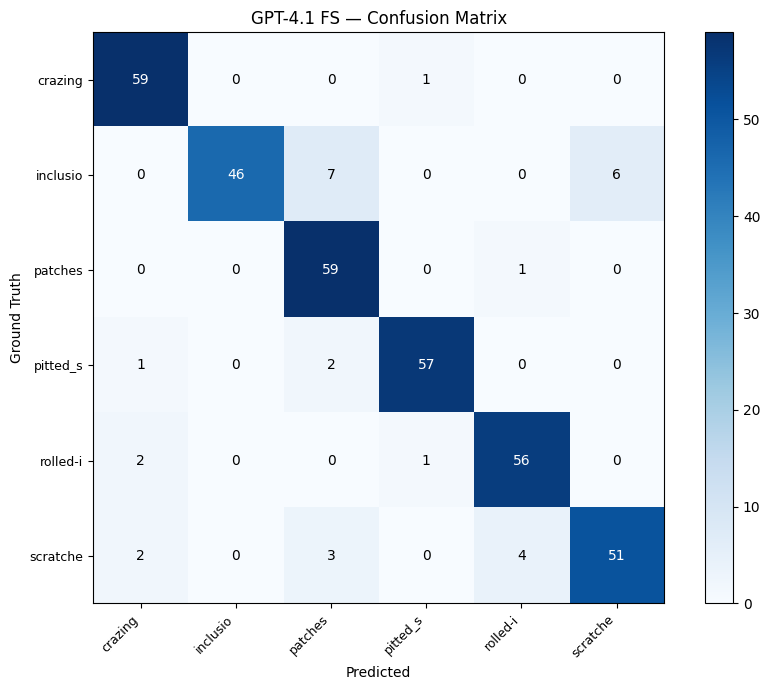

(2 responses could not be parsed)


In [13]:
# Pick the best frontier result for confusion matrix
best_label, best_results = max(all_runs, key=lambda x: sum(1 for r in x[1] if r['correct']))
print(f'Confusion matrix for: {best_label}\n')

# Build confusion matrix
cm = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
cls_to_idx = {c: i for i, c in enumerate(CLASSES)}
unparsed = 0
for r in best_results:
    gt_idx = cls_to_idx[r['class']]
    if r['predicted']:
        pred = r['predicted'].get('defect_class', '').lower().strip()
        if pred in cls_to_idx:
            cm[gt_idx, cls_to_idx[pred]] += 1
        else:
            unparsed += 1
    else:
        unparsed += 1

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(CLASSES))); ax.set_yticks(range(len(CLASSES)))
short_labels = [c[:8] for c in CLASSES]
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)
ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')
ax.set_title(f'{best_label} — Confusion Matrix')
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        color = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', color=color, fontsize=10)
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()
if unparsed: print(f'({unparsed} responses could not be parsed)')

## Save Results

In [14]:
for label, results, correct, valid, tt, model_name in [
    ('gpt41_zs', gpt41_zs_results, gpt41_zs_correct, gpt41_zs_valid, gpt41_zs_time, 'gpt-4.1'),
    ('gpt41_fs', gpt41_fs_results, gpt41_fs_correct, gpt41_fs_valid, gpt41_fs_time, 'gpt-4.1'),
    ('gpt5_zs',  gpt5_zs_results,  gpt5_zs_correct,  gpt5_zs_valid,  gpt5_zs_time,  'gpt-5'),
    ('gpt5_fs',  gpt5_fs_results,  gpt5_fs_correct,  gpt5_fs_valid,  gpt5_fs_time,  'gpt-5'),
]:
    n = len(results)
    fname = f'benchmark_results_frontier_{label}.json'
    with open(fname, 'w') as f:
        json.dump({
            'model': model_name, 'mode': label, 'dataset': 'NEU-CLS',
            'total_images': n,
            'accuracy_pct': round(correct/n*100, 1),
            'json_validity_pct': round(valid/n*100, 1),
            'avg_inference_time_s': round(tt/n, 2),
            'results': results
        }, f, indent=2)
    print(f'Saved {fname}')

print('\nDone. All frontier benchmark results saved.')

Saved benchmark_results_frontier_gpt41_zs.json
Saved benchmark_results_frontier_gpt41_fs.json
Saved benchmark_results_frontier_gpt5_zs.json
Saved benchmark_results_frontier_gpt5_fs.json

Done. All frontier benchmark results saved.
